# Data Visualization with Matplotlib

Estimated time needed: **40** minutes

## Objectives

After completing this lab you will be able to:

*   Explore features or characteristics that relate to California housing prices
*   Create **line**, **scatter**, **bar**, and **histogram** plots
*   Combine multiple plots with **subplots**



<h2>Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href="#import_data">Import Data</a></li>
    <li><a href="#line_plot">Line Plot</a></li>
    <li><a href="#scatter_plot">Scatter Plot</a></li>
    <li><a href="#bar_plot">Bar Plot</a></li>
    <li><a href="#hist_plot">Histogram</a></li>
    <li><a href="#subplots">Subplots</a></li>
</ol>

</div>

<hr>


<h3>What are the main characteristics that have the most impact on the house value (<code>gia_nha_trung_vi</code>)?</h3>
<h3>Đặc trưng nào ảnh hưởng mạnh nhất đến giá nhà (<code>gia_nha_trung_vi</code>)?</h3>


<h2 id="import_data">1. Import Data</h2>


<h4>Setup</h4>


Import libraries:


In [14]:
import pandas as pd
import numpy as np


Load the data and store it in dataframe `df`. Dùng <code>pd.read_csv</code> với biến <code>filename</code> ở cell trên.

Load the CSV with <code>pd.read_csv(filename)</code>.


In [15]:
import kagglehub
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)
import os
os.listdir(path)
filename = os.path.join(path, 'housing.csv')


Path to dataset files: C:\Users\TUAN\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


In [16]:
df = pd.read_csv(filename)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<p>Để dễ theo dõi, đổi tên cột sang tiếng Việt rồi xem lại <code>df.head()</code>.</p>
<p>Rename columns to Vietnamese, then display the first rows again.</p>


In [17]:
df = df.rename(columns={
    "longitude": "kinh_do",
    "latitude": "vi_do",
    "housing_median_age": "tuoi_nha",
    "total_rooms": "tong_phong",
    "total_bedrooms": "tong_phong_ngu",
    "population": "dan_so",
    "households": "so_ho",
    "median_income": "thu_nhap_trung_vi",
    "median_house_value": "gia_nha_trung_vi",
    "ocean_proximity": "vi_tri_bien",
})
df.head()


,kinh_do,vi_do,tuoi_nha,tong_phong,tong_phong_ngu,dan_so,so_ho,thu_nhap_trung_vi,gia_nha_trung_vi,vi_tri_bien
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<p><b>Từ điển cột sau khi đổi tên</b> (tên cũ → tên mới):</p>
<ul>
    <li><code>longitude</code> → <code>kinh_do</code>: kinh độ. Càng về phía tây (Pacific) thì số càng âm (khoảng −124 → −114).</li>
    <li><code>latitude</code> → <code>vi_do</code>: vĩ độ. Càng ra bắc thì số càng lớn (khoảng 32 → 42). Cặp kinh độ + vĩ độ = vị trí khối census trên bản đồ California.</li>
    <li><code>housing_median_age</code> → <code>tuoi_nha</code>: tuổi trung vị của nhà trong khối (năm). Không phải tuổi từng căn, mà mức giữa của khu.</li>
    <li><code>total_rooms</code> → <code>tong_phong</code>: tổng số phòng trong khối.</li>
    <li><code>total_bedrooms</code> → <code>tong_phong_ngu</code>: tổng số phòng ngủ. Cột này có thể có giá trị thiếu (NaN).</li>
    <li><code>population</code> → <code>dan_so</code>: dân số của khối.</li>
    <li><code>households</code> → <code>so_ho</code>: số hộ gia đình.</li>
    <li><code>median_income</code> → <code>thu_nhap_trung_vi</code>: thu nhập trung vị. Trong dataset California Housing, đơn vị là <b>10.000 USD</b> (ví dụ 8.3252 ≈ 83.252 USD/năm).</li>
    <li><code>median_house_value</code> → <code>gia_nha_trung_vi</code>: giá nhà trung vị (USD) — <b>biến đích (target)</b>. Nhiều giá trị bị cắt trần khoảng 500.001.</li>
    <li><code>ocean_proximity</code> → <code>vi_tri_bien</code>: vị trí so với biển (biến phân loại).</li>
</ul>
<p><b>Giá trị của <code>vi_tri_bien</code>:</b></p>
<ul>
    <li><code>&lt;1H OCEAN</code>: cách biển dưới 1 giờ đi lại — nhiều khối nhất.</li>
    <li><code>INLAND</code>: nội địa, xa biển — thường giá nhà thấp hơn.</li>
    <li><code>NEAR OCEAN</code>: sát bờ đại dương.</li>
    <li><code>NEAR BAY</code>: gần vịnh (San Francisco Bay) — thường giá cao.</li>
    <li><code>ISLAND</code>: đảo — rất ít dòng, khó kết luận.</li>
</ul>
<p>Dataset <b>không có tên thành phố</b>. So sánh “lớn / nhỏ” theo <code>vi_tri_bien</code>.</p>


<h2 id="pattern_visualization">2. Analyzing Individual Feature Patterns Using Visualization</h2>


Import visualization packages "Matplotlib" and "Seaborn". Don't forget about "%matplotlib inline" to plot in a Jupyter notebook.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


<div class="alert alert-block alert-info" style="margin-top: 20px">
<h4>Bảng lệnh nhanh / Cheat sheet</h4>
<p>Nhớ 4 hàm này. Demo ở mỗi mục dùng đúng hàm đó; câu hỏi chỉ <b>đổi cột / thêm hue / đổi API</b>.</p>
<p>Remember these four calls. Each section demos one; questions only <b>change columns / add color / switch API</b>.</p>
<pre>
plt.plot(x, y)                          # line
plt.scatter(x, y, s=..., c=..., alpha=) # scatter
ax.bar(tên, giá_trị)                    # bar đứng / vertical
ax.barh(tên, giá_trị)                   # bar ngang / horizontal
plt.hist(cột, bins=30, edgecolor="black")
fig, ax = plt.subplots()                # OO: một hình
fig, ax = plt.subplots(2, 2, figsize=(12, 8))  # OO: lưới / grid
ax[0, 0].plot(...)                      # ô hàng 0, cột 0
</pre>
<p>Series sau <code>groupby(...)[cột].mean()</code> hoặc <code>value_counts()</code>: <code>.index</code> = nhãn, <code>.values</code> = số.</p>
<p>After <code>groupby</code> / <code>value_counts</code>: <code>.index</code> = labels, <code>.values</code> = numbers.</p>
</div>


<h4>How to choose the right visualization method?</h4>
<p>When visualizing individual variables, it is important to first understand what type of variable you are dealing with. This will help us find the right visualization method for that variable.</p>
<p>Khi vẽ từng biến, hãy xác định kiểu dữ liệu trước để chọn đúng biểu đồ.</p>
<p>Chạy cell dưới để xem <code>df.dtypes</code> — đây là <b>code mẫu</b>, không cần sửa.</p>
<p>Run the cell below — it is a <b>worked example</b>.</p>


In [19]:
# Kiểu dữ liệu từng cột / Data type of each column
df.dtypes

kinh_do              float64
vi_do                float64
tuoi_nha             float64
tong_phong           float64
tong_phong_ngu       float64
dan_so               float64
so_ho                float64
thu_nhap_trung_vi    float64
gia_nha_trung_vi     float64
vi_tri_bien           object
dtype: object

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #1:</h3>

<b>What is the data type of the column <code>vi_tri_bien</code>?</b><br/>
Kiểu dữ liệu của cột <code>vi_tri_bien</code> là gì?

<p><b>Gợi ý / Hint:</b> cell trên đã in toàn bộ <code>df.dtypes</code>. Muốn lấy <b>một cột</b>: <code>df["tên_cột"]</code> rồi <code>.dtype</code>.</p>
</div>


In [49]:
# Write your code below
df['vi_tri_bien'].dtype



dtype('O')

The default setting of "describe" skips variables of type object. We can apply the method "describe" on the variables of type 'object' as follows:

Mặc định <code>describe()</code> bỏ cột kiểu object. Cell dưới là <b>code mẫu</b> — chạy để xem thống kê cột phân loại.

The next cell is a <b>worked example</b>.


In [21]:
# Thống kê cột kiểu object (chuỗi / phân loại)
df.describe(include=["object"])


,vi_tri_bien
count,20640
unique,5
top,<1H OCEAN
freq,9136


<h2 id="line_plot">3. Line Plot</h2>


<p>Housing is not a time series, but <code>tuoi_nha</code> still has an order. If we group by age and take the mean house value, we can draw a line.</p>
<p>Dataset housing không phải chuỗi thời gian, nhưng <code>tuoi_nha</code> vẫn có thứ tự. Gom nhóm theo tuổi nhà rồi lấy giá trung bình, ta có thể vẽ line.</p>


Let's plot the mean of "gia_nha_trung_vi" against "tuoi_nha".

Hai cell dưới là <b>demo đầy đủ</b>: groupby rồi vẽ line. Chạy để xem mẫu, câu hỏi #2 sẽ nhờ bạn vẽ <i>hai</i> đường tương tự.

The next two cells are a <b>complete demo</b> (groupby + line plot). Question #2 asks you to draw <i>two</i> lines the same way.


In [22]:
# Demo — bước 1 / step 1: groupby rồi lấy trung bình
# groupby "tuoi_nha", mean of "gia_nha_trung_vi"  →  Series (index = tuổi nhà)
by_age = df.groupby("tuoi_nha")["gia_nha_trung_vi"].mean()
by_age.head()


tuoi_nha
1.0    144300.000000
2.0    224475.913793
3.0    235643.580645
4.0    229235.136126
5.0    208417.655738
Name: gia_nha_trung_vi, dtype: float64

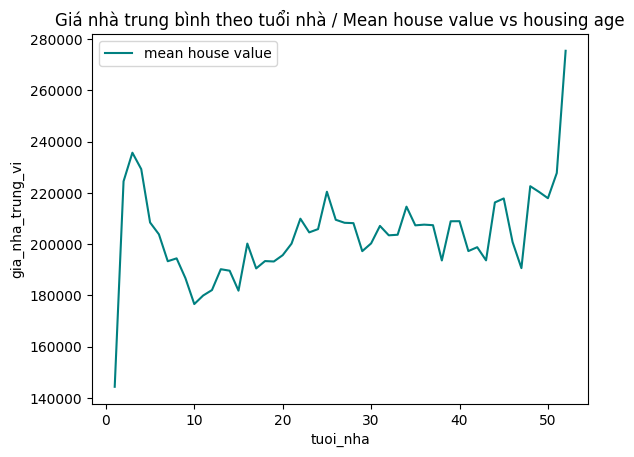

In [23]:
# Demo — bước 2 / step 2: vẽ line từ Series
# by_age.index = trục x (tuoi_nha),  by_age.values = trục y (giá TB)
plt.plot(by_age.index, by_age.values, color="teal", linestyle="-", label="mean house value")
plt.xlabel("tuoi_nha")
plt.ylabel("gia_nha_trung_vi")
plt.title("Giá nhà trung bình theo tuổi nhà / Mean house value vs housing age")
plt.legend()
plt.show()


<p><b>Nhận xét từ hình vẽ / Look at the plot and answer:</b></p>
<ul>
    <li>Khi tuổi nhà tăng, giá trung bình thế nào?<br/>As housing age increases, what happens to the mean house value?</li>
    <li>Có xu hướng tăng ra sao? Đường có thẳng đều không?<br/>How does it trend? Is it a simple straight line?</li>
    <li>Tuổi nhà có liên quan đến giá không? Có phải predictor tuyến tính hoàn hảo không?<br/>Is housing age related to price? Is it a perfect linear predictor?</li>
</ul>


In [ ]:
# Write your conclusion
#Khi tuổi nhà tăng, giá trung bình sẽ giảm
#Nhà có xu hướng tăng khi khoảng dưới 5 năm tuổi, giảm sau 5 năm tuổi và tăng mạnh thì trên 50 năm
#Tuổi nhà có liên quan tới giá

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #2:</h3>

<p>On the same axes, plot two lines: the mean of <code>gia_nha_trung_vi</code> vs <code>tuoi_nha</code> for <code>INLAND</code> and for <code>NEAR BAY</code>.</p>
<p>Cùng một axes, vẽ hai đường: giá nhà trung bình theo tuổi nhà — một đường <code>INLAND</code>, một đường <code>NEAR BAY</code>.</p>

<p>Làm <b>giống demo line</b> (groupby + <code>plt.plot</code>), nhưng phải lọc 2 nhóm rồi vẽ <b>hai lần</b>.</p>
<p>Same as the line demo, but filter two groups and call <code>plt.plot</code> twice.</p>

<p><b>Gợi ý / Hint</b> (không phải đáp án — tự ghép các bước):</p>
<ul>
<li>Lọc: <code>df[df["cột"] == "giá_trị"]</code></li>
<li>Groupby: copy demo <code>by_age = df.groupby(...)[...].mean()</code>, áp lên từng nhóm</li>
<li>Vẽ: <code>plt.plot(series.index, series.values, label="...")</code> hai lần, nhớ <code>plt.legend()</code></li>
</ul>
</div>


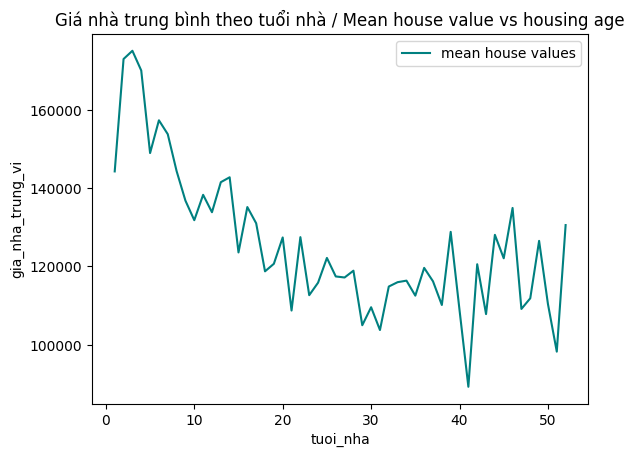

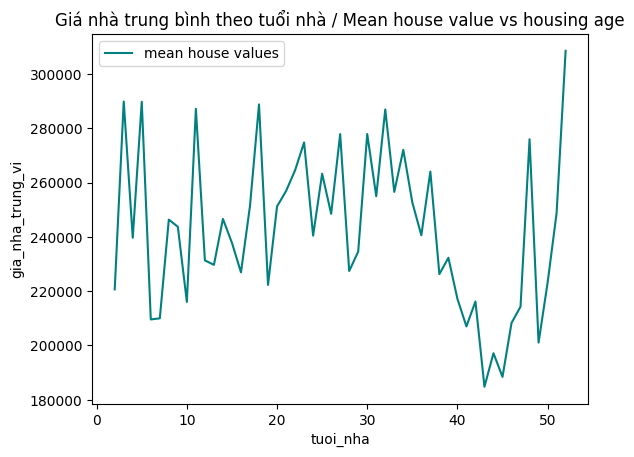

In [56]:
# Write your code below
# 1. lọc INLAND và NEAR BAY
INLAND = df[df['vi_tri_bien'] == 'INLAND']
NEAR_BAY = df[df['vi_tri_bien'] == 'NEAR BAY']

# 2. groupby tuoi_nha → mean gia_nha_trung_vi (như demo by_age)
by_age1 = INLAND.groupby('tuoi_nha')['gia_nha_trung_vi'].mean()
by_age2 = NEAR_BAY.groupby('tuoi_nha')['gia_nha_trung_vi'].mean()
# 3. plt.plot hai lần, xlabel / ylabel / title / legend / show
plt.plot(by_age1.index, by_age1.values, color='teal', linestyle ='-', label='mean house values' )
plt.xlabel('tuoi_nha')
plt.ylabel('gia_nha_trung_vi')
plt.title('Giá nhà trung bình theo tuổi nhà / Mean house value vs housing age')
plt.legend()
plt.show()
plt.plot(by_age2.index, by_age2.values, color='teal', linestyle ='-', label='mean house values' )
plt.xlabel('tuoi_nha')
plt.ylabel('gia_nha_trung_vi')
plt.title('Giá nhà trung bình theo tuổi nhà / Mean house value vs housing age')
plt.legend()
plt.show()





In [ ]:
# Write your conclusion
# Gợi ý nhận xét / Hint — nhìn 2 đường rồi trả lời:
# - Đường nào cao hơn? Khu nào (INLAND hay NEAR BAY) có giá nhà trung bình đắt hơn?
#Near Bay có giá trung bình đắt hơn
# - Khoảng cách giữa 2 đường có giữ xuyên suốt các mức tuổi nhà không?
#Không
# - Có đoạn tuổi nào hai đường gần nhau hoặc cắt nhau không?



<h2 id="scatter_plot">4. Scatter Plot</h2>


<h2>Continuous Numerical Variables:</h2>

<p>Continuous numerical variables are variables that may contain any value within some range. They can be of type "int64" or "float64". A great way to visualize these variables is by using scatterplots.</p>

<p>Biến số liên tục có thể nhận mọi giá trị trong một khoảng. Cách trực quan phổ biến là scatter plot.</p>


Let's see several examples of different relationships:


<h3>Geographic relationship</h3>


Let's find the scatterplot of "kinh_do" and "vi_do".

Cell code kế tiếp là <b>demo</b>: lấy 2 cột rồi <code>plt.scatter</code>. <code>s=1</code> (marker nhỏ) và <code>alpha=0.4</code> (trong suốt) để 20.000 điểm không che nhau.

The next cell is a <b>demo</b>. Small <code>s</code> and <code>alpha</code> keep ~20k points readable.


<p>When extracting two columns, unpack the Series, not the DataFrame. Iterating a DataFrame yields <b>column names</b> (strings), so this mistake plots only <b>one point</b>:</p>
<pre>lat, lon = df[['vi_do', 'kinh_do']]   # WRONG — lat becomes the string "vi_do"</pre>
<p>Khi unpack DataFrame, pandas lấy <b>tên cột</b> (chuỗi), nên scatter chỉ ra 1 điểm — không phải do marker quá nhỏ.</p>


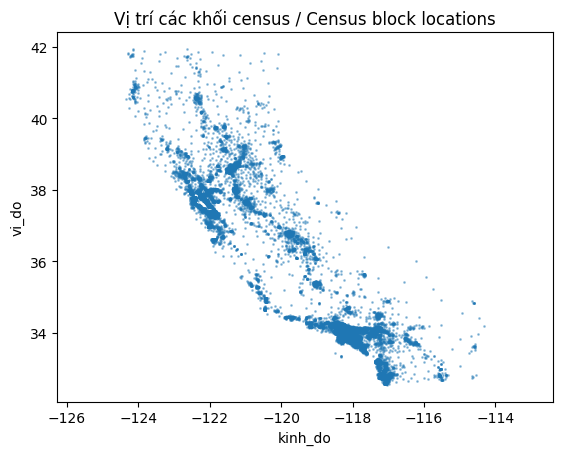

In [27]:
# Demo — bản đồ California / California map (x = kinh độ, y = vĩ độ)
lat = df["vi_do"]
lon = df["kinh_do"]

plt.scatter(lon, lat, s=1, alpha=0.4)
plt.xlabel("kinh_do")
plt.ylabel("vi_do")
plt.title("Vị trí các khối census / Census block locations")
plt.axis("equal")
plt.show()


In [28]:
# Write your conclusion
# - Marker nhỏ / alpha để làm gì?


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #3:</h3>

<p>Using the same map, encode <b>color</b> by <code>np.log10(dan_so)</code> and <b>size</b> by <code>tong_phong</code>. Add a colorbar.</p>
<p>Cùng bản đồ, mã hóa <b>màu</b> theo log dân số và <b>kích thước</b> theo tổng số phòng. Thêm colorbar.</p>

<p>Bắt đầu từ demo scatter (<code>lon</code>, <code>lat</code> đã có). Tự thêm tham số, đừng copy nguyên đáp án.</p>
<p>Start from the scatter demo (<code>lon</code>, <code>lat</code> already exist). Add the extra arguments yourself.</p>

<p><b>Gợi ý / Hint:</b></p>
<ul>
<li>Màu / color: tham số <code>c=</code> và <code>cmap="viridis"</code></li>
<li>Cỡ điểm / size: tham số <code>s=</code> (chia cho một số, ví dụ 50, cho đỡ to)</li>
<li>Colorbar: <code>plt.colorbar(label="...")</code></li>
<li>Nhớ <code>xlabel</code>, <code>ylabel</code>, <code>title</code>, <code>axis("equal")</code></li>
</ul>
</div>


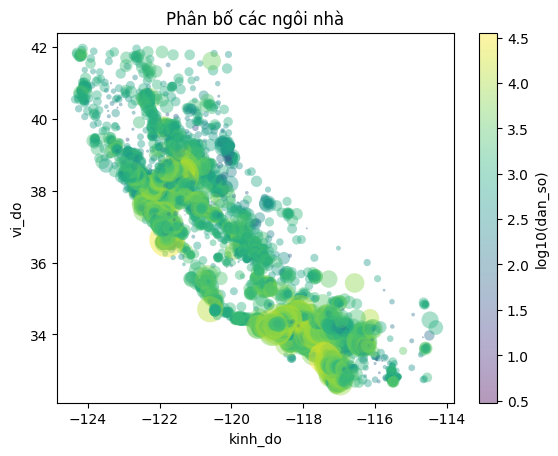

In [57]:
# Write your code below
# plt.scatter(lon, lat, ...)  rồi colorbar, nhãn trục, show
plt.scatter(
    lon,
    lat,
    alpha=0.4,
    c=np.log10(df["dan_so"]),
    cmap="viridis",
    s=df["tong_phong"] / 50,
    linewidth=0,
)
plt.colorbar(label="log10(dan_so)")
plt.xlabel("kinh_do")
plt.ylabel("vi_do")
plt.title("Phân bố các ngôi nhà")
plt.axis("equal")
plt.show()


<h3>Positive Linear Relationship</h3>


<h4>Theory: Correlation / Tương quan (<code>corr</code>)</h4>
<p>Hệ số tương quan Pearson đo <b>mức độ quan hệ tuyến tính</b> giữa hai biến số. Kết quả nằm trong khoảng <b>[-1, 1]</b>.</p>
<ul>
    <li><b>corr &gt; 0</b> (positive): x tăng thì y có xu hướng <b>tăng</b> — đúng với tiêu đề <i>Positive Linear Relationship</i>.</li>
    <li><b>corr &lt; 0</b> (negative): x tăng thì y có xu hướng <b>giảm</b>.</li>
    <li><b>corr ≈ 0</b>: gần như <b>không</b> có quan hệ tuyến tính (điểm rải, đường gần nằm ngang).</li>
    <li><b>|corr| càng gần 1</b> thì quan hệ tuyến tính càng mạnh; càng gần 0 thì càng yếu.</li>
    <li>Gợi ý đọc nhanh: |corr| &lt; 0.3 yếu; khoảng 0.3–0.7 vừa; &gt; 0.7 mạnh. (Không phải quy tắc tuyệt đối.)</li>
</ul>
<p>Đường chéo của ma trận <code>corr()</code> luôn bằng <b>1</b> (một biến tự tương quan với chính nó). <b>Tương quan không phải nhân quả</b> (correlation ≠ causation).</p>

<p><b>Nhận xét từ hình vẽ / Look at the scatter and answer:</b></p>
<ul>
    <li>Khi <code>thu_nhap_trung_vi</code> tăng, <code>gia_nha_trung_vi</code> đi theo hướng nào? (tăng / giảm / không rõ)</li>
    <li>Các điểm bám sát một đường thẳng hay phân tán? Đây có phải predictor tuyến tính hoàn hảo không?</li>
    <li>Có dải ngang / trần giá bất thường gần 500.000 không?</li>
    <li>Theo lý thuyết trên, bạn kỳ vọng <code>corr</code> dương hay âm? Gần 0 hay gần 1?</li>
</ul>


<p>Vẽ scatter <code>thu_nhap_trung_vi</code> (x) theo <code>gia_nha_trung_vi</code> (y), rồi tính hệ số tương quan bằng <code>corr()</code>.</p>
<p>Scatter income vs house value, then compute Pearson correlation with <code>corr()</code>.</p>
<p>Cell dưới là <b>demo đầy đủ</b> (scatter + corr). Question #4 sẽ dùng OO API và thêm màu.</p>
<p>The next cell is a <b>complete demo</b>. Question #4 uses the OO API and adds color.</p>


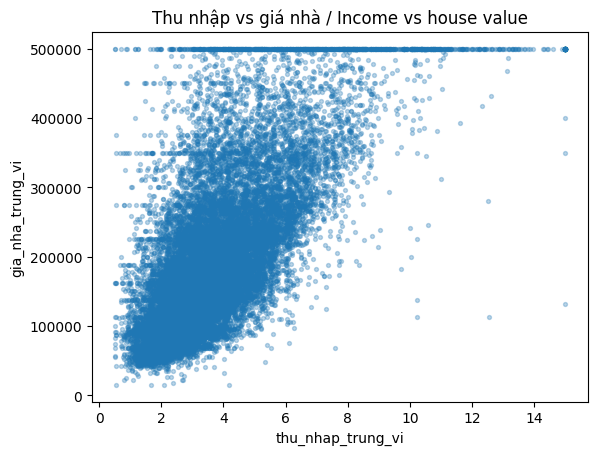

,thu_nhap_trung_vi,gia_nha_trung_vi
thu_nhap_trung_vi,1.000000,0.688075
gia_nha_trung_vi,0.688075,1.000000


In [30]:
# Demo — scatter + corr
plt.scatter(df["thu_nhap_trung_vi"], df["gia_nha_trung_vi"], alpha=0.3, s=8)
plt.xlabel("thu_nhap_trung_vi")
plt.ylabel("gia_nha_trung_vi")
plt.title("Thu nhập vs giá nhà / Income vs house value")
plt.show()

# Ô không nằm trên đường chéo mới là corr giữa 2 biến
# The off-diagonal value is the correlation between the two columns
df[["thu_nhap_trung_vi", "gia_nha_trung_vi"]].corr()


In [31]:
# Write your conclusion
#  nhìn scatter + bảng corr:
# - corr dương hay âm? gần 0 hay gần 1?
# - Có khớp với hướng các điểm trên scatter không?
# - Vì sao không phải 1.0? (điểm phân tán? trần giá?)


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #4:</h3>

<p>Using the OO API (<code>fig, ax = plt.subplots()</code>), scatter <code>thu_nhap_trung_vi</code> (x) vs <code>gia_nha_trung_vi</code> (y). Color the points by <code>tuoi_nha</code> and add a colorbar.</p>
<p>Dùng OO API, vẽ scatter thu nhập (x) theo giá nhà (y). Tô màu theo tuổi nhà và thêm colorbar.</p>

<p>Khác demo: dùng <code>ax.scatter</code> (không phải <code>plt.scatter</code>).</p>
<p>Unlike the demo: use <code>ax.scatter</code>, not <code>plt.scatter</code>.</p>

<p><b>Gợi ý / Hint:</b></p>
<ul>
<li><code>fig, ax = plt.subplots()</code></li>
<li>Gán kết quả scatter vào biến, ví dụ <code>img = ax.scatter(x, y, c=..., cmap="viridis")</code></li>
<li>Colorbar gắn figure: <code>fig.colorbar(img, ax=ax)</code></li>
<li>Nhãn: <code>ax.set(xlabel=..., ylabel=..., title=...)</code></li>
</ul>
</div>


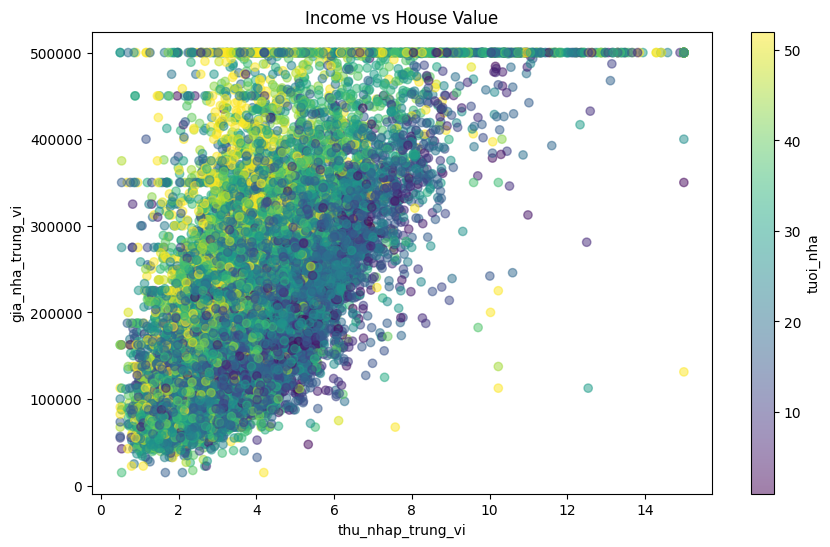

In [60]:
# Write your code below
fig, ax = plt.subplots(figsize=(10, 6))

img = ax.scatter(
    df["thu_nhap_trung_vi"],
    df["gia_nha_trung_vi"],
    c=df["tuoi_nha"],
    cmap="viridis",
    alpha=0.5
)

ax.set_xlabel("thu_nhap_trung_vi")
ax.set_ylabel("gia_nha_trung_vi")
ax.set_title("Income vs House Value")

fig.colorbar(img, ax=ax, label="tuoi_nha")

plt.show()




In [33]:
# Write your conclusion

<h2 id="bar_plot">5. Bar Plot</h2>


<h3>Categorical Variables</h3>

<p>These are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using bar plots (counts or group means).</p>

<p>Biến phân loại mô tả một đặc trưng, lấy từ một nhóm nhỏ các hạng mục. Cách trực quan phổ biến là bar (đếm) hoặc bar theo trung bình nhóm.</p>


<h3>Value Counts</h3>


<p>Value counts is a good way of understanding how many units of each characteristic/variable we have. We can apply the "value_counts" method on the column "vi_tri_bien". Don’t forget the method "value_counts" only works on pandas series, not pandas dataframes. As a result, we only include one bracket <code>df['vi_tri_bien']</code>, not two brackets <code>df[['vi_tri_bien']]</code>.</p>


In [34]:
df["vi_tri_bien"].value_counts()


vi_tri_bien
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Let's look at the relationship between "vi_tri_bien" and the number of census blocks.

Từ intro Matplotlib: <code>ax.bar(tên_nhóm, số_đếm)</code>. Cell dưới là <b>demo</b> — <code>value_counts()</code> cho <code>.index</code> (tên) và <code>.values</code> (số lượng).

From the Matplotlib intro: <code>ax.bar(categories, counts)</code>. The next cell is a <b>demo</b>.


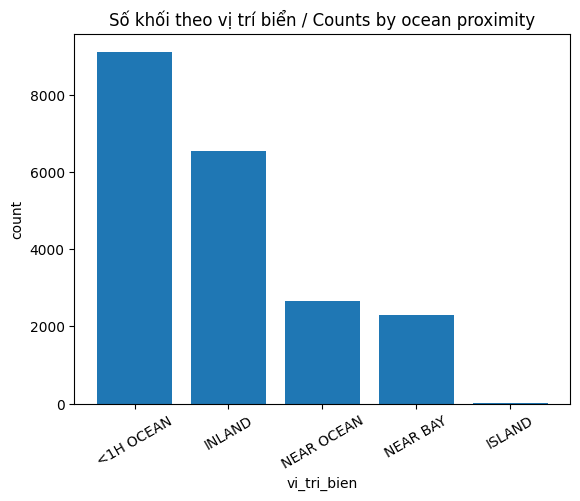

In [35]:
# Demo — bar dọc / vertical bar (số khối theo vi_tri_bien)
counts = df["vi_tri_bien"].value_counts()

fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
ax.set(title="Số khối theo vị trí biển / Counts by ocean proximity",
       xlabel="vi_tri_bien", ylabel="count")
plt.xticks(rotation=30)
plt.show()


<p>Most districts are <code>&lt;1H OCEAN</code> or <code>INLAND</code>. <code>ISLAND</code> has very few rows, so conclusions about that category will be weak.</p>
<p>Phần lớn các khối thuộc <code>&lt;1H OCEAN</code> hoặc <code>INLAND</code>. <code>ISLAND</code> rất ít dòng nên khó rút kết luận cho nhóm này.</p>


<p>If we want to know, on average, which ocean-proximity category is most valuable, we can group "vi_tri_bien" and then average "gia_nha_trung_vi".</p>


In [36]:
df_group_one = df[["vi_tri_bien", "gia_nha_trung_vi"]]
df_group_one = df_group_one.groupby(["vi_tri_bien"], as_index=False).mean()
df_group_one


,vi_tri_bien,gia_nha_trung_vi
0,<1H OCEAN,240084.285464
1,INLAND,124805.392001
2,ISLAND,380440.000000
3,NEAR BAY,259212.311790
4,NEAR OCEAN,249433.977427


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #5:</h3>

<p>Draw a <b>horizontal</b> bar chart of the mean <code>gia_nha_trung_vi</code> for each <code>vi_tri_bien</code>.</p>
<p>Vẽ bar <b>ngang</b> (<code>barh</code>) giá nhà trung bình theo từng <code>vi_tri_bien</code>.</p>

<p>Demo trên là bar <b>đứng</b> + đếm số dòng. Câu này: bar <b>ngang</b> + bảng <code>df_group_one</code> (giá trung bình) ở cell trước.</p>
<p>The demo is a <b>vertical</b> count bar. Here: <b>horizontal</b> bar of means in <code>df_group_one</code>.</p>

<p><b>Gợi ý / Hint:</b> <code>ax.barh(nhãn, giá_trị)</code> — hai cột của <code>df_group_one</code>. Nhớ <code>ax.set(...)</code> và <code>plt.show()</code>.</p>
</div>


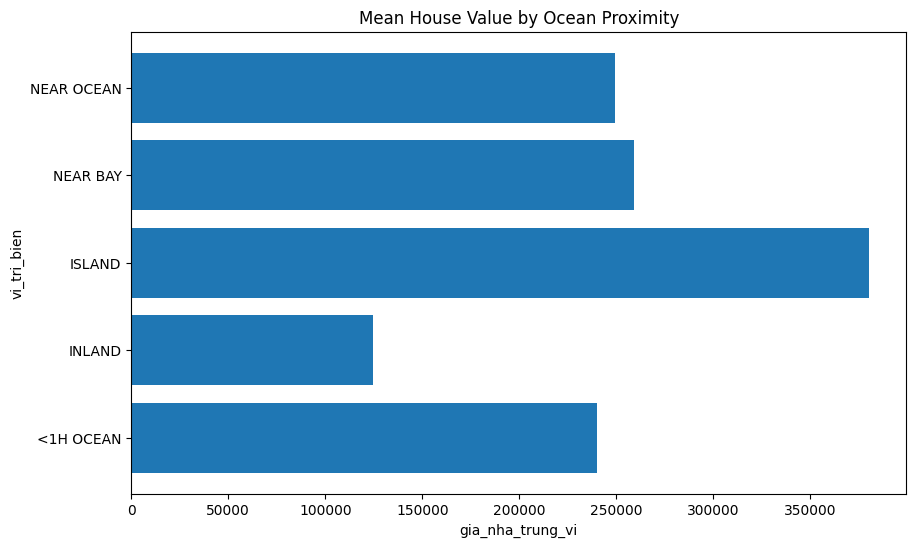

In [61]:
# Write your code below
mean_price = df.groupby(
    "vi_tri_bien"
)["gia_nha_trung_vi"].mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    mean_price.index,
    mean_price.values
)

ax.set_xlabel("gia_nha_trung_vi")
ax.set_ylabel("vi_tri_bien")
ax.set_title("Mean House Value by Ocean Proximity")

plt.show()



In [38]:
# Write your conclusion
#  Hint — nhìn barh giá nhà TB theo vi_tri_bien:
# - Nhóm nào đắt nhất? Nhóm nào rẻ nhất?
# - INLAND so với các nhóm gần biển (NEAR BAY, NEAR OCEAN, <1H OCEAN) thế nào?
# - ISLAND có đáng tin không? (nhớ value_counts: nhóm này có nhiều dòng không?)


<h2 id="hist_plot">6. Histogram</h2>


<p>A histogram shows the <b>frequency</b> of a continuous variable. You do not need to group the data first.</p>
<p>Histogram mô tả tần suất của một biến liên tục — không cần groupby trước.</p>
<p>Cell dưới là <b>demo</b> <code>plt.hist</code> cho <code>gia_nha_trung_vi</code>. Question #6 dùng OO API cho cột khác.</p>
<p>The next cell is a <b>pyplot demo</b>. Question #6 uses the OO API on another column.</p>


Let's find the histogram of "gia_nha_trung_vi".


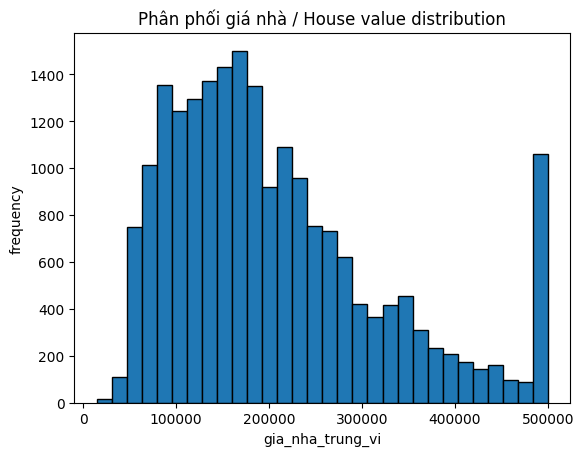

In [39]:
# Demo — histogram (pyplot)
plt.hist(df["gia_nha_trung_vi"], bins=30, edgecolor="black")
plt.xlabel("gia_nha_trung_vi")
plt.ylabel("frequency")
plt.title("Phân phối giá nhà / House value distribution")
plt.show()


<p><b>Gợi ý đọc histogram / How to read a histogram:</b></p>
<ul>
    <li><b>Lệch phải (right-skewed)</b>: đuôi dài về bên phải — nhiều giá trị vừa/phải, một số rất lớn.</li>
    <li><b>Lệch trái (left-skewed)</b>: đuôi dài về bên trái.</li>
    <li><b>Đối xứng</b>: hai bên gần giống nhau (gần phân phối chuẩn).</li>
</ul>
<p><b>Nhận xét từ hình vẽ / Look at the plot and answer:</b></p>
<ul>
    <li>Phân phối <code>gia_nha_trung_vi</code> lệch trái, lệch phải, hay khá đối xứng?</li>
    <li>Có cụm / cột bất thường ở đầu phải (gần giá trị lớn nhất ~500.000) không?</li>
    <li>Nếu có, điều đó gợi ý giá nhà bị <b>cắt trần (capped)</b> không? Việc này ảnh hưởng thế nào nếu sau này dự đoán giá nhà?</li>
</ul>


In [40]:
# Write your conclusion
# Gợi ý nhận xét / Hint:
# - Lệch trái / lệch phải / đối xứng?
# - Có cột cao bất thường gần max (~500.000) không?
# - Có phải giá bị cắt trần? Việc này có ảnh hưởng khi predict không?


Using the OO API we can label the counts on each bar.

Dùng OO API để ghi số đếm trên từng cột. Cell dưới là <b>demo</b> cho <code>tuoi_nha</code> — Question #6 copy mẫu này, đổi cột và <code>bins</code>.

The next cell is a <b>demo</b> on <code>tuoi_nha</code>. Question #6: copy it, change the column and <code>bins</code>.


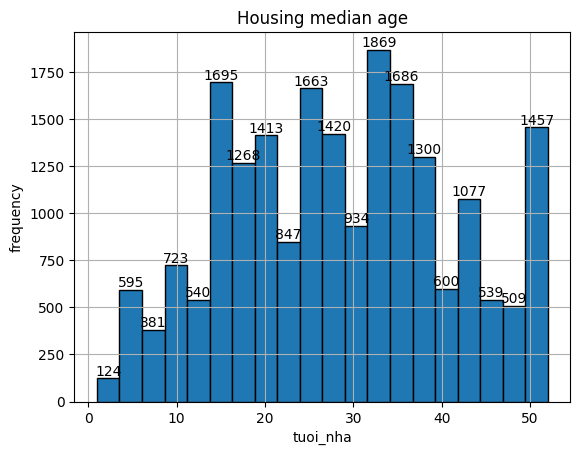

In [41]:
fig, ax = plt.subplots()
n, bins, patches = ax.hist(df["tuoi_nha"], bins=20, edgecolor="black")
ax.set(title="Housing median age", xlabel="tuoi_nha", ylabel="frequency")
ax.bar_label(patches)
ax.grid(True)
plt.show()


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #6:</h3>

<p>Plot a histogram of <code>thu_nhap_trung_vi</code> with <code>bins=30</code> and black edges. Use the OO API and <code>ax.bar_label(patches)</code>.</p>
<p>Vẽ histogram <code>thu_nhap_trung_vi</code>, <code>bins=30</code>, viền đen. Dùng OO API và <code>ax.bar_label(patches)</code>.</p>

<p>Mẫu nằm ở cell demo <code>tuoi_nha</code> ngay phía trên. Đổi cột, đổi <code>bins</code>, sửa title/xlabel — <b>tự gõ lại</b>, không copy nguyên rồi nộp.</p>
<p>The worked example is the <code>tuoi_nha</code> demo above. Change the column and <code>bins</code>; type it yourself.</p>
</div>


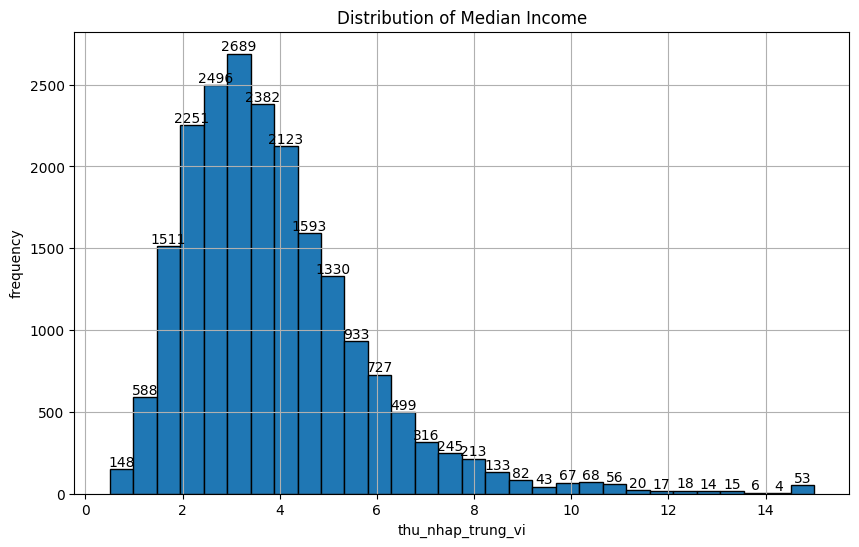

In [62]:
# Write your code below
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(
    df["thu_nhap_trung_vi"],
    bins=30,
    edgecolor="black"
)

ax.set(
    title="Distribution of Median Income",
    xlabel="thu_nhap_trung_vi",
    ylabel="frequency"
)

ax.bar_label(patches)

ax.grid(True)

plt.show()



In [43]:
# Write your conclusion

<h2 id="subplots">7. Subplots</h2>


<p>The OO API can split one figure into a grid. There are two equivalent options.</p>
<p>OO API chia một figure thành lưới. Có hai cách tương đương.</p>
<p><b>Option 1</b> (cell demo dưới) gán tên <code>ax1, ax2, ...</code>. <b>Question #7</b> vẽ <i>cùng nội dung</i> bằng Option 2: <code>ax[hàng, cột]</code>.</p>
<p><b>Option 1</b> unpacks named axes. <b>Question #7</b> redraws the <i>same</i> grid with Option 2 indexing.</p>


<h4>Option 1: unpack each axes</h4>


Let's put a line, a scatter, a bar, and a histogram on a 2×2 grid.


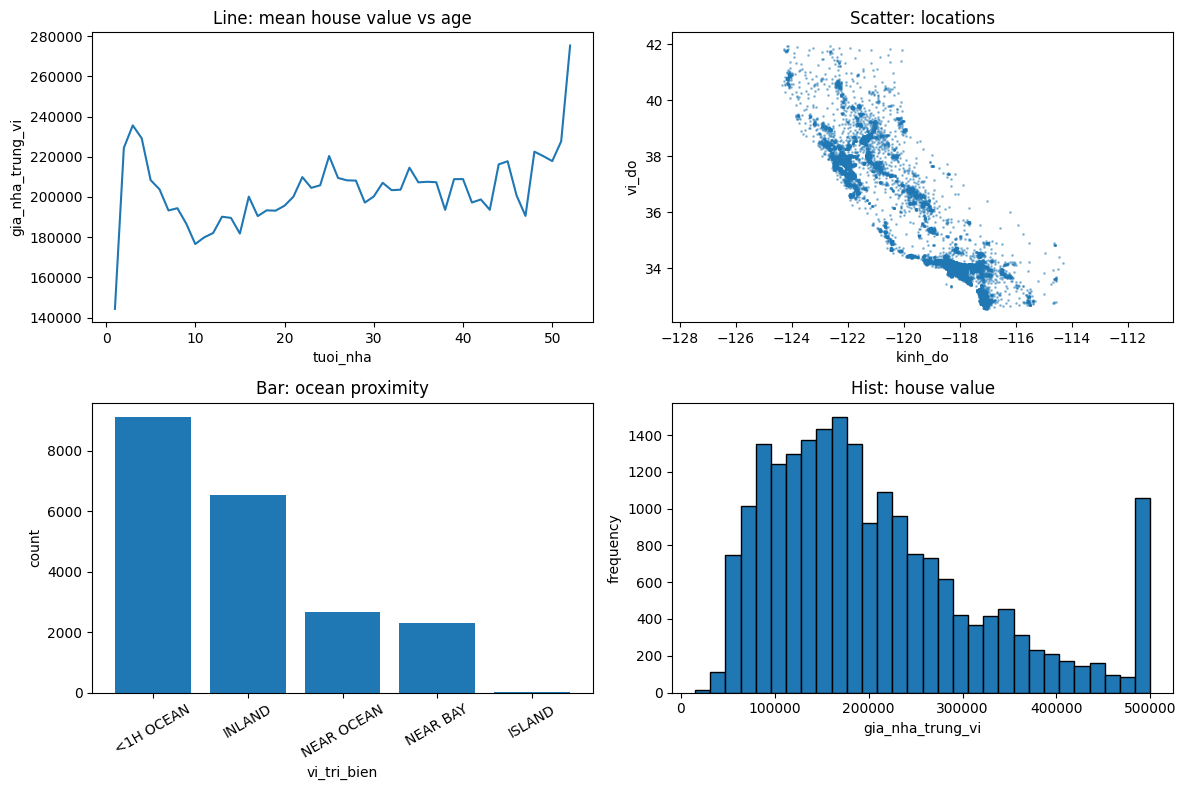

In [44]:
fig, [(ax1, ax2), (ax3, ax4)] = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

ax1.plot(by_age.index, by_age.values)
ax1.set(title="Line: mean house value vs age", xlabel="tuoi_nha", ylabel="gia_nha_trung_vi")

ax2.scatter(lon, lat, s=1, alpha=0.4)
ax2.set(title="Scatter: locations", xlabel="kinh_do", ylabel="vi_do")
ax2.axis("equal")

ax3.bar(counts.index, counts.values)
ax3.set(title="Bar: ocean proximity", xlabel="vi_tri_bien", ylabel="count")
ax3.tick_params(axis="x", rotation=30)

ax4.hist(df["gia_nha_trung_vi"], bins=30, edgecolor="black")
ax4.set(title="Hist: house value", xlabel="gia_nha_trung_vi", ylabel="frequency")

fig.tight_layout()
plt.show()


<p>Each axes is an independent plot: line, scatter, bar, and hist share one figure. <code>fig.tight_layout()</code> keeps titles and labels from overlapping.</p>
<p>Mỗi axes là một biểu đồ độc lập. <code>tight_layout()</code> giúp tiêu đề và nhãn không chồng lên nhau.</p>


<h4>Option 2: index the axes array</h4>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #7:</h3>

<p>Redraw the same 2×2 figure using option 2: <code>fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))</code> and <code>ax[0, 0]</code>, <code>ax[0, 1]</code>, <code>ax[1, 0]</code>, <code>ax[1, 1]</code>.</p>
<p>Vẽ lại lưới 2×2 <b>giống Option 1</b>, nhưng dùng chỉ số <code>ax[row, col]</code>.</p>

<p><b>Gợi ý / Hint:</b> không vẽ plot mới. Đổi tên axes:</p>
<ul>
<li><code>ax1</code> → <code>ax[0, 0]</code></li>
<li><code>ax2</code> → <code>ax[0, 1]</code></li>
<li><code>ax3</code> → <code>ax[1, 0]</code></li>
<li><code>ax4</code> → <code>ax[1, 1]</code></li>
</ul>
<p>Dữ liệu dùng lại: <code>by_age</code>, <code>lon</code>, <code>lat</code>, <code>counts</code>. Kết thúc bằng <code>fig.tight_layout()</code>.</p>
</div>


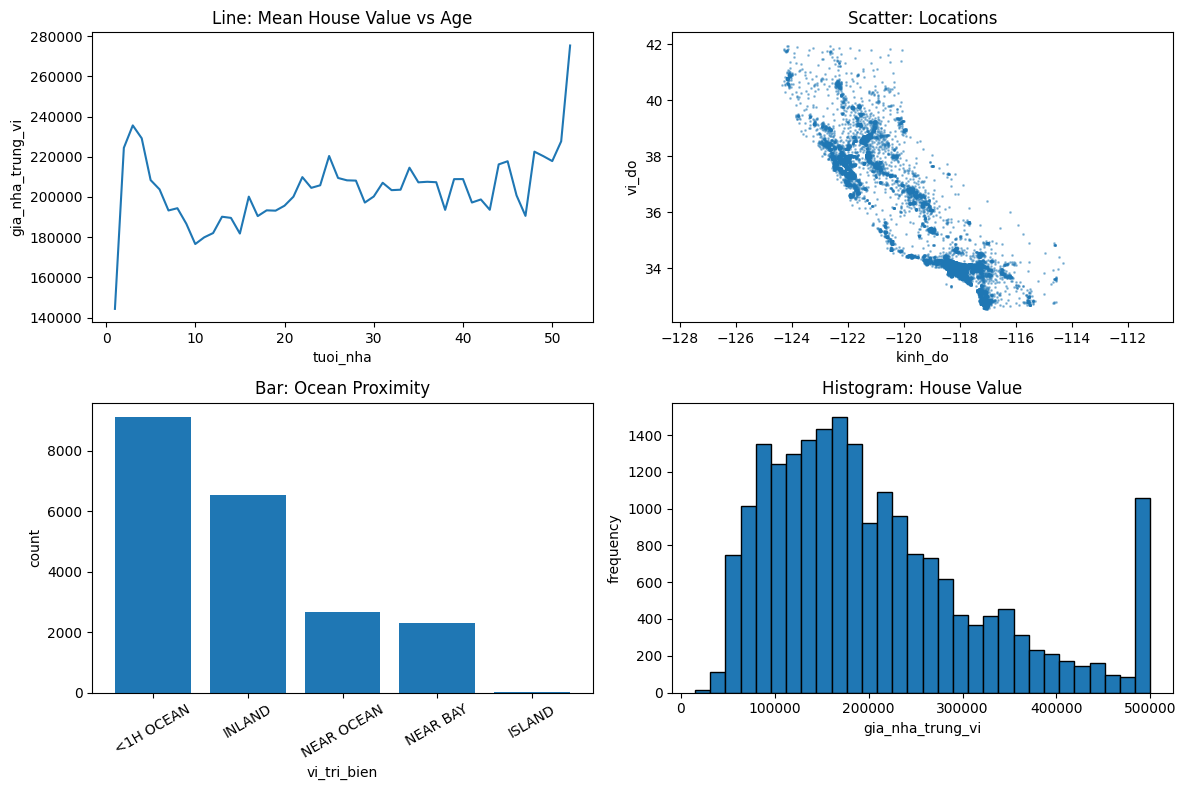

In [63]:
# Write your code below
# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
# ax[0, 0]. ...
# ax[0, 1]. ...
# ax[1, 0]. ...
# ax[1, 1]. ...
fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

# 1. Line plot
ax[0, 0].plot(
    by_age.index,
    by_age.values
)

ax[0, 0].set(
    title="Line: Mean House Value vs Age",
    xlabel="tuoi_nha",
    ylabel="gia_nha_trung_vi"
)


# 2. Scatter plot
ax[0, 1].scatter(
    lon,
    lat,
    s=1,
    alpha=0.4
)

ax[0, 1].set(
    title="Scatter: Locations",
    xlabel="kinh_do",
    ylabel="vi_do"
)

ax[0, 1].axis("equal")


# 3. Bar plot
ax[1, 0].bar(
    counts.index,
    counts.values
)

ax[1, 0].set(
    title="Bar: Ocean Proximity",
    xlabel="vi_tri_bien",
    ylabel="count"
)

ax[1, 0].tick_params(
    axis="x",
    rotation=30
)


# 4. Histogram
ax[1, 1].hist(
    df["gia_nha_trung_vi"],
    bins=30,
    edgecolor="black"
)

ax[1, 1].set(
    title="Histogram: House Value",
    xlabel="gia_nha_trung_vi",
    ylabel="frequency"
)


fig.tight_layout()

plt.show()



<h3>Conclusion: Important Variables</h3>


<p>We now have a better idea of what our data looks like and which variables are important to take into account when predicting the house value. From the plots above, we have narrowed it down to the following variables:</p>

Continuous numerical variables:

<ul>
    <li>thu_nhap_trung_vi</li>
    <li>tuoi_nha</li>
    <li>kinh_do / vi_do (location)</li>
    <li>dan_so / tong_phong (size of the district)</li>
</ul>

Categorical variables:

<ul>
    <li>vi_tri_bien</li>
</ul>

<p>As we now move into building machine learning models to automate our analysis, feeding the model with variables that meaningfully affect our target variable will improve our model's prediction performance.</p>


<p>Hướng dẫn <b>chung</b> cách nhìn line / scatter / bar / histogram / subplots để viết nhận xét: xem notebook <code>w3_4_How-to-Read-Plots.ipynb</code> (không gắn với dataset housing).</p>
<p>For a <b>general</b> guide on reading those plot types and writing comments, see <code>w3_4_How-to-Read-Plots.ipynb</code> (not tied to this housing dataset).</p>
